In [14]:
!pip -q install \
transitleastsquares \
lightkurve \
astropy \
astroquery \
wotan \
plotly \
pyarrow \
tqdm \
batman-package

In [15]:
import gc
import json
import logging
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import plotly.graph_objects as go

from tqdm.notebook import tqdm

from astropy.timeseries import BoxLeastSquares

from transitleastsquares import (
    transitleastsquares,
    transit_mask
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [16]:
PROJECT_NAME = "Exoplanet-detection"

ROOT_DIR = Path("D:/MachineLearning") / PROJECT_NAME

PROCESSED_DIR = ROOT_DIR / "data" / "processed" / "lightcurves"

QUALITY_REPORT = ROOT_DIR / "reports" / "quality_metrics.csv"

CANDIDATE_DIR = ROOT_DIR / "data" / "processed" / "candidates"

REPORT_DIR = ROOT_DIR / "reports"

TLS_DIR = REPORT_DIR / "tls"

BLS_DIR = REPORT_DIR / "bls"

FOLDED_DIR = REPORT_DIR / "folded_curves"

LOG_DIR = ROOT_DIR / "logs"

CANDIDATE_DIR.mkdir(parents=True, exist_ok=True)
TLS_DIR.mkdir(parents=True, exist_ok=True)
BLS_DIR.mkdir(parents=True, exist_ok=True)
FOLDED_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration loaded.")

Project configuration loaded.


In [17]:

MIN_PERIOD = 0.5         # days
MAX_PERIOD = 20.0         # days

MIN_DURATION = 0.04       # days (~1 hour)
MAX_DURATION = 0.5       # days (~12 hours)

MIN_SDE = 7.0

MIN_TRANSITS = 2

print("Detection parameters loaded.")

Detection parameters loaded.


In [18]:
LOG_FILE = LOG_DIR / "notebook_04.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ],
    force=True
)

logger = logging.getLogger("Notebook04")

logger.info("Notebook 04 Started")

2026-07-23 23:44:58,434 | INFO | Notebook 04 Started


In [19]:
processed_files = sorted(PROCESSED_DIR.glob("*.parquet"))

print("=" * 60)
print(f"Processed Light Curves Found : {len(processed_files):,}")
print("=" * 60)

if len(processed_files) == 0:
    raise FileNotFoundError("No processed light curves found.")

Processed Light Curves Found : 89


In [20]:
quality_df = pd.read_csv(QUALITY_REPORT)

print(f"Quality Report Loaded : {len(quality_df):,} rows")

quality_df.head()

Quality Report Loaded : 89 rows


,tic_id,sector,mission,author,target_name,cadence_sec,num_points,mean_flux,median_flux,std_flux,...,skewness,kurtosis,missing_values,duplicate_times,missing_fraction,duplicate_fraction,estimated_transit_depth,lowest_flux,file_name,status
0,100990000,3,TESS,SPOC,100990000,21.661595,13532,1.000003,1.0,0.000316,...,0.069340,0.132021,0,0,0.0,0.0,0.001210,0.998790,TIC_100990000_Sector_3.parquet,Success
1,120252452,40,TESS,SPOC,120252452,22.335620,19611,1.000077,1.0,0.008784,...,0.010462,0.111957,0,0,0.0,0.0,0.034610,0.965390,TIC_120252452_Sector_40.parquet,Success
2,120422519,53,TESS,SPOC,120422519,19.787113,16991,0.999908,1.0,0.014823,...,-0.012335,0.062769,0,0,0.0,0.0,0.062193,0.937807,TIC_120422519_Sector_53.parquet,Success
3,120691237,80,TESS,SPOC,120691237,20.947567,17255,0.999880,1.0,0.018543,...,-0.019136,0.361775,0,0,0.0,0.0,0.083770,0.916230,TIC_120691237_Sector_80.parquet,Success
4,121395761,40,TESS,SPOC,121395761,22.335706,19609,0.999922,1.0,0.019285,...,-0.009120,0.115879,0,0,0.0,0.0,0.079758,0.920242,TIC_121395761_Sector_40.parquet,Success


In [21]:
sample = pd.read_parquet(processed_files[0])

sample.head()

,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
0,100990000,3,TESS,SPOC,100990000,21.661595,1385.950975,0.999648,40.051029,0,128491.154483
1,100990000,3,TESS,SPOC,100990000,21.661595,1385.952364,1.000761,40.076237,0,128491.278858
2,100990000,3,TESS,SPOC,100990000,21.661595,1385.953753,1.000269,40.061535,0,128491.029725
3,100990000,3,TESS,SPOC,100990000,21.661595,1385.955142,0.999865,40.054287,0,128490.664490
4,100990000,3,TESS,SPOC,100990000,21.661595,1385.956531,1.000046,40.054855,0,128490.364681


In [22]:
required_columns = [

    "time",

    "flux",

    "flux_err"

]

missing = [

    col for col in required_columns

    if col not in sample.columns

]

if missing:

    raise ValueError(f"Missing columns: {missing}")

print("Required columns verified.")

Required columns verified.


In [23]:

print(sample.info())

display(sample.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13532 entries, 0 to 13531
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tic_id       13532 non-null  int64  
 1   sector       13532 non-null  int64  
 2   mission      13532 non-null  object 
 3   author       13532 non-null  object 
 4   target_name  13532 non-null  int64  
 5   cadence_sec  13532 non-null  float64
 6   time         13532 non-null  float64
 7   flux         13532 non-null  float64
 8   flux_err     13532 non-null  float32
 9   quality      13532 non-null  int32  
 10  trend        13532 non-null  float64
dtypes: float32(1), float64(4), int32(1), int64(3), object(2)
memory usage: 1.0+ MB
None


,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
count,13532.0,13532.0,13532,13532,13532.0,1.353200e+04,13532.000000,13532.000000,13532.000000,13532.0,13532.000000
unique,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,TESS,SPOC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,13532,13532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1396.085615,1.000003,40.117222,0.0,128490.586597
std,0.0,0.0,NaN,NaN,0.0,1.065853e-14,6.037814,0.000316,0.236273,0.0,7.371790
min,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1385.950975,0.998790,40.024426,0.0,128471.574302
25%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1390.703520,0.999793,40.049965,0.0,128486.451715
50%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1396.708842,1.000000,40.057339,0.0,128490.487245
75%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1401.451633,1.000214,40.065331,0.0,128495.523097


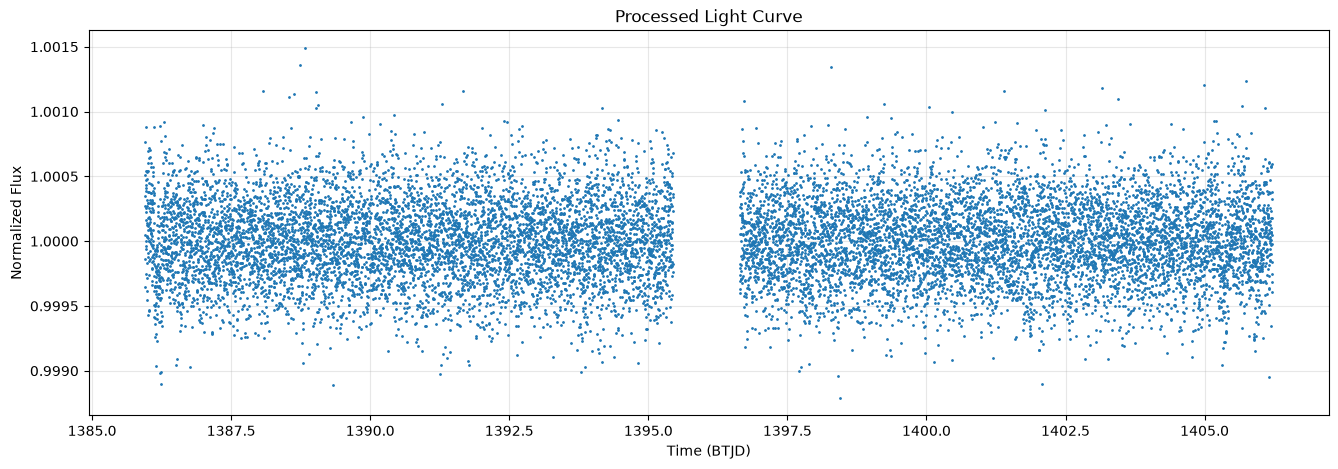

In [24]:
plt.figure(figsize=(16,5))

plt.plot(
    sample["time"],
    sample["flux"],
    ".",
    markersize=2
)

plt.xlabel("Time (BTJD)")

plt.ylabel("Normalized Flux")

plt.title("Processed Light Curve")

plt.grid(alpha=0.3)

plt.show()

In [25]:
print(f"Processed Curves : {len(processed_files):,}")

print(f"Candidate Folder : {CANDIDATE_DIR}")

print(f"TLS Reports      : {TLS_DIR}")

print(f"BLS Reports      : {BLS_DIR}")

logger.info("Setup completed successfully.")

2026-07-23 23:44:58,951 | INFO | Setup completed successfully.


Processed Curves : 89
Candidate Folder : D:\MachineLearning\Exoplanet-detection\data\processed\candidates
TLS Reports      : D:\MachineLearning\Exoplanet-detection\reports\tls
BLS Reports      : D:\MachineLearning\Exoplanet-detection\reports\bls


In [26]:
# Candidate Selection

MIN_POINTS = 1000
MIN_PHOTOMETRIC_SNR = 20.0
MAX_RMS = 0.02

snr_column = (
    "photometric_snr"
    if "photometric_snr" in quality_df.columns
    else "snr"
)

quality_candidates = quality_df.copy()

quality_candidates = quality_candidates[
    (quality_candidates["status"] == "Success") &
    (quality_candidates["num_points"] >= MIN_POINTS) &
    (quality_candidates[snr_column] >= MIN_PHOTOMETRIC_SNR) &
    (quality_candidates["rms"] <= MAX_RMS)
].reset_index(drop=True)

print(f"Total Processed Curves : {len(quality_df):,}")
print(f"Selected for TLS       : {len(quality_candidates):,}")

Total Processed Curves : 89
Selected for TLS       : 55


In [27]:
# Save Selection Report

selection_report = CANDIDATE_DIR / "selected_lightcurves.csv"

quality_candidates.to_csv(
    selection_report,
    index=False
)

print(f"Saved: {selection_report}")

Saved: D:\MachineLearning\Exoplanet-detection\data\processed\candidates\selected_lightcurves.csv


In [28]:
# Transit Least Squares Search

def run_tls(df):

    model = transitleastsquares(

        df["time"].values,

        df["flux"].values,

        df["flux_err"].values

    )

    results = model.power(

        period_min=MIN_PERIOD,

        period_max=MAX_PERIOD,

        show_progress_bar=False

    )

    return results

In [29]:
# Extract TLS Parameters

def extract_tls_results(results):

    return {

        "period": float(results.period),

        "duration": float(results.duration),

        "depth": float(results.depth),

        "transit_time": float(results.T0),

        "sde": float(results.SDE),

        "snr": float(results.snr),

        "odd_even_mismatch": float(results.odd_even_mismatch),

        "distinct_transit_count": int(results.distinct_transit_count)

    }

In [30]:
# TLS Example

tls_results = run_tls(sample)

sample_tls = extract_tls_results(tls_results)

sample_tls

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 36 durations
Searching 13532 data points, 1744 periods from 0.601 to 10.133 days
Using all 16 CPU threads
Searching for best T0 for period 9.58105 days


{'period': 9.581046366528344,
 'duration': 0.08891951669765669,
 'depth': 0.9997199591750052,
 'transit_time': 1386.1848582548562,
 'sde': 9.485988836829423,
 'snr': 8.836414640577472,
 'odd_even_mismatch': nan,
 'distinct_transit_count': 2}

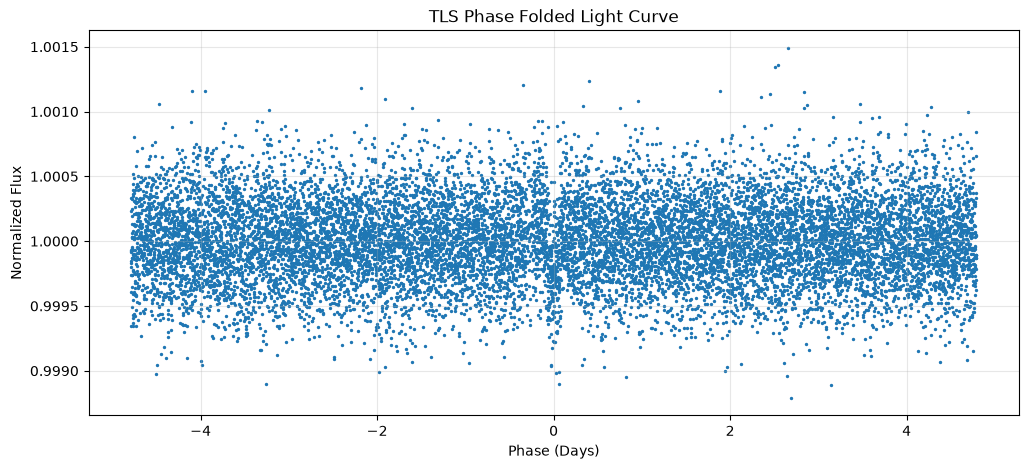

In [31]:
# Phase Fold

phase = (

    (sample["time"] - tls_results.T0 + 0.5 * tls_results.period)

    %

    tls_results.period

) - 0.5 * tls_results.period

plt.figure(figsize=(12,5))

plt.scatter(

    phase,

    sample["flux"],

    s=2

)

plt.xlabel("Phase (Days)")

plt.ylabel("Normalized Flux")

plt.title("TLS Phase Folded Light Curve")

plt.grid(alpha=0.3)

plt.show()

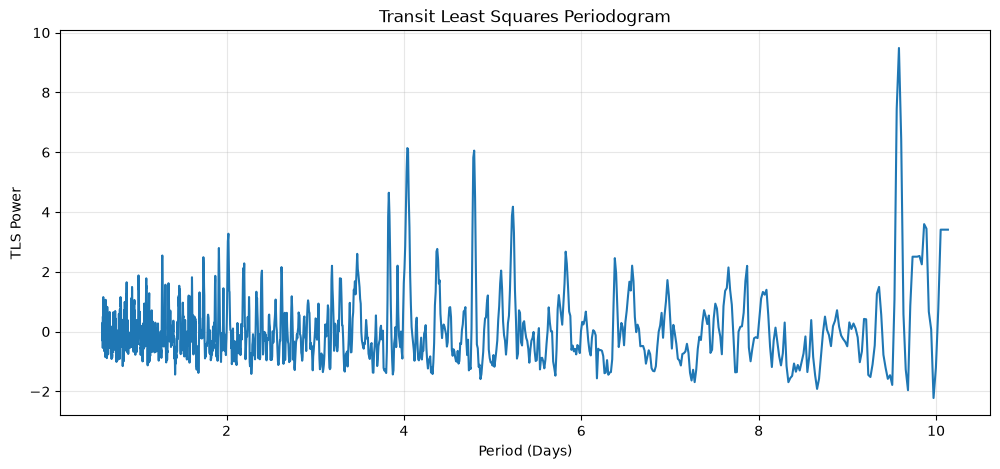

In [32]:
# TLS Periodogram

plt.figure(figsize=(12,5))

plt.plot(

    tls_results.periods,

    tls_results.power

)

plt.xlabel("Period (Days)")

plt.ylabel("TLS Power")

plt.title("Transit Least Squares Periodogram")

plt.grid(alpha=0.3)

plt.show()

In [34]:
# Save Sample TLS Results

sample_tls_df = pd.DataFrame([sample_tls])

sample_tls_df.to_csv(

    TLS_DIR / "sample_tls_results.csv",

    index=False

)

sample_tls_df

,period,duration,depth,transit_time,sde,snr,odd_even_mismatch,distinct_transit_count
0,9.581046,0.08892,0.99972,1386.184858,9.485989,8.836415,NaN,2


In [35]:
# Detection Validation

print(f"Period              : {tls_results.period:.5f} days")

print(f"Duration            : {tls_results.duration:.5f} days")

print(f"Transit Depth       : {tls_results.depth:.6f}")

print(f"SDE                 : {tls_results.SDE:.2f}")

print(f"Transit SNR         : {tls_results.snr:.2f}")

print(f"Detected Transits   : {tls_results.distinct_transit_count}")


if tls_results.SDE >= MIN_SDE:

    print(" Candidate passes SDE threshold.")

else:

    print(" Candidate below SDE threshold.")

Period              : 9.58105 days
Duration            : 0.08892 days
Transit Depth       : 0.999720
SDE                 : 9.49
Transit SNR         : 8.84
Detected Transits   : 2
 Candidate passes SDE threshold.
